In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
week1 = pd.read_csv('week1_baseline.csv')
week2 = pd.read_csv('week2_drift.csv')
week3 = pd.read_csv('week3_drift.csv')
week4 = pd.read_csv('week4_drift.csv')

print("All datasets loaded!")
print("Week 1 shape:", week1.shape)
print("Week 2 shape:", week2.shape)
print("Week 3 shape:", week3.shape)
print("Week 4 shape:", week4.shape)


All datasets loaded!
Week 1 shape: (71201, 31)
Week 2 shape: (71201, 31)
Week 3 shape: (71201, 31)
Week 4 shape: (71204, 31)


In [3]:
features = ['V1', 'V2', 'Amount']

print("KS Test Results:")
print("-" * 50)

for feature in features:
    ks_week2 = stats.ks_2samp(week1[feature], week2[feature])
    ks_week3 = stats.ks_2samp(week1[feature], week3[feature])
    ks_week4 = stats.ks_2samp(week1[feature], week4[feature])
    
    print(f"\nFeature: {feature}")
    print(f"Week 2 - KS Statistic: {ks_week2.statistic:.4f}, P-value: {ks_week2.pvalue:.6f}")
    print(f"Week 3 - KS Statistic: {ks_week3.statistic:.4f}, P-value: {ks_week3.pvalue:.6f}")
    print(f"Week 4 - KS Statistic: {ks_week4.statistic:.4f}, P-value: {ks_week4.pvalue:.6f}")

KS Test Results:
--------------------------------------------------

Feature: V1
Week 2 - KS Statistic: 0.2776, P-value: 0.000000
Week 3 - KS Statistic: 0.5765, P-value: 0.000000
Week 4 - KS Statistic: 0.7457, P-value: 0.000000

Feature: V2
Week 2 - KS Statistic: 0.2307, P-value: 0.000000
Week 3 - KS Statistic: 0.4726, P-value: 0.000000
Week 4 - KS Statistic: 0.6786, P-value: 0.000000

Feature: Amount
Week 2 - KS Statistic: 0.0480, P-value: 0.000000
Week 3 - KS Statistic: 0.0816, P-value: 0.000000
Week 4 - KS Statistic: 0.1012, P-value: 0.000000


In [4]:
def calculate_psi(base, current, bins=10):
    base_counts, bin_edges = np.histogram(base, bins=bins)
    current_counts, _ = np.histogram(current, bins=bin_edges)
    
    base_pct = base_counts / len(base) + 1e-6
    current_pct = current_counts / len(current) + 1e-6
    
    psi = np.sum((current_pct - base_pct) * np.log(current_pct / base_pct))
    return psi

print("PSI Results:")
print("-" * 50)

for feature in features:
    psi_week2 = calculate_psi(week1[feature], week2[feature])
    psi_week3 = calculate_psi(week1[feature], week3[feature])
    psi_week4 = calculate_psi(week1[feature], week4[feature])
    
    print(f"\nFeature: {feature}")
    print(f"Week 2 PSI: {psi_week2:.4f}")
    print(f"Week 3 PSI: {psi_week3:.4f}")
    print(f"Week 4 PSI: {psi_week4:.4f}")

print("\nPSI Guide:")
print("PSI < 0.1  = No drift")
print("PSI 0.1-0.2 = Slight drift")
print("PSI > 0.2  = Significant drift")

PSI Results:
--------------------------------------------------

Feature: V1
Week 2 PSI: 0.0187
Week 3 PSI: 0.3518
Week 4 PSI: 0.8409

Feature: V2
Week 2 PSI: 0.2098
Week 3 PSI: 0.8379
Week 4 PSI: 1.4436

Feature: Amount
Week 2 PSI: 0.0002
Week 3 PSI: 0.0032
Week 4 PSI: 0.0098

PSI Guide:
PSI < 0.1  = No drift
PSI 0.1-0.2 = Slight drift
PSI > 0.2  = Significant drift


In [5]:
def calculate_kl_divergence(base, current, bins=10):
    base_counts, bin_edges = np.histogram(base, bins=bins)
    current_counts, _ = np.histogram(current, bins=bin_edges)
    
    base_pct = base_counts / len(base) + 1e-6
    current_pct = current_counts / len(current) + 1e-6
    
    kl = np.sum(base_pct * np.log(base_pct / current_pct))
    return kl

print("KL Divergence Results:")
print("-" * 50)

for feature in features:
    kl_week2 = calculate_kl_divergence(week1[feature], week2[feature])
    kl_week3 = calculate_kl_divergence(week1[feature], week3[feature])
    kl_week4 = calculate_kl_divergence(week1[feature], week4[feature])
    
    print(f"\nFeature: {feature}")
    print(f"Week 2 KL Divergence: {kl_week2:.4f}")
    print(f"Week 3 KL Divergence: {kl_week3:.4f}")
    print(f"Week 4 KL Divergence: {kl_week4:.4f}")

print("\nKL Divergence Guide:")
print("KL < 0.1  = No drift")
print("KL 0.1-0.5 = Moderate drift")
print("KL > 0.5  = Significant drift")

KL Divergence Results:
--------------------------------------------------

Feature: V1
Week 2 KL Divergence: 0.1384
Week 3 KL Divergence: 0.6989
Week 4 KL Divergence: 1.2015

Feature: V2
Week 2 KL Divergence: 0.1018
Week 3 KL Divergence: 0.4242
Week 4 KL Divergence: 0.7770

Feature: Amount
Week 2 KL Divergence: 0.0001
Week 3 KL Divergence: 0.0014
Week 4 KL Divergence: 0.0038

KL Divergence Guide:
KL < 0.1  = No drift
KL 0.1-0.5 = Moderate drift
KL > 0.5  = Significant drift


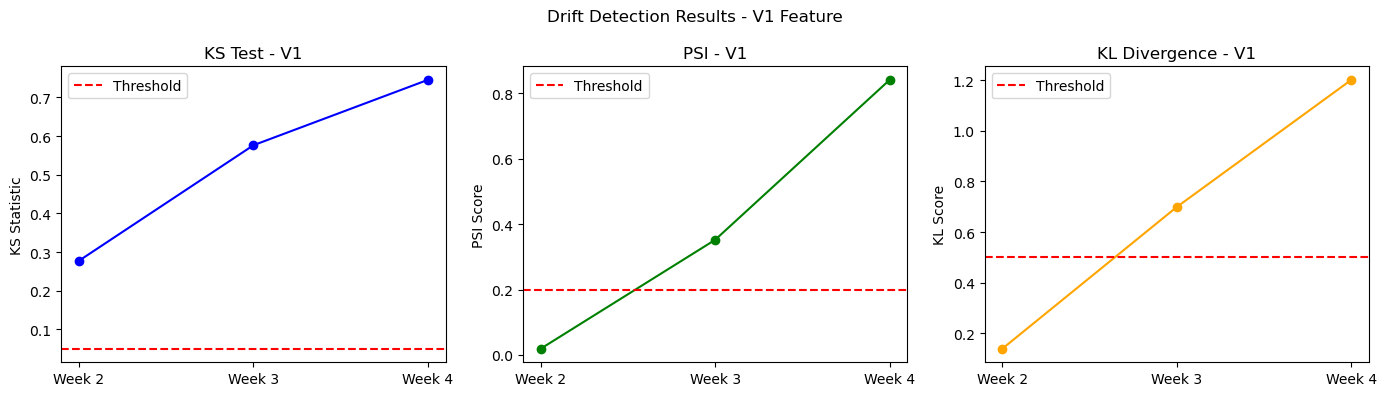

In [7]:
weeks = ['Week 2', 'Week 3', 'Week 4']

ks_v1 = [0.2776, 0.5765, 0.7457]
psi_v1 = [0.0187, 0.3518, 0.8409]
kl_v1 = [0.1384, 0.6989, 1.2015]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(weeks, ks_v1, marker='o', color='blue')
axes[0].set_title('KS Test - V1')
axes[0].set_ylabel('KS Statistic')
axes[0].axhline(y=0.05, color='red', linestyle='--', label='Threshold')
axes[0].legend()

axes[1].plot(weeks, psi_v1, marker='o', color='green')
axes[1].set_title('PSI - V1')
axes[1].set_ylabel('PSI Score')
axes[1].axhline(y=0.2, color='red', linestyle='--', label='Threshold')
axes[1].legend()

axes[2].plot(weeks, kl_v1, marker='o', color='orange')
axes[2].set_title('KL Divergence - V1')
axes[2].set_ylabel('KL Score')
axes[2].axhline(y=0.5, color='red', linestyle='--', label='Threshold')
axes[2].legend()

plt.suptitle('Drift Detection Results - V1 Feature')
plt.tight_layout()
plt.show()
